# Raw-field diversity behind the curated BioSample fields

This notebook analyzes `data/derived/trace_back_full.parquet` -- the trace-back check built by another agent's ongoing job, which deterministically verifies each LLM-extracted value against the raw BioSample record it came from (see `notebooks/biosample_input_output_pilot.ipynb` for how that check works).

That job is still running (~95% of the crate traced back as of this notebook's last run) but writes to the same fixed path every time (`paths.TRACE_BACK_FULL_PARQUET`, unchanged since it was first introduced) -- so this notebook always reads the latest snapshot fresh, with no version-tracking needed on this end.

The focus here is different from the pilot notebook: not "was each value traced back successfully" but "what does the raw metadata field-naming landscape actually look like" -- across the ~9 curated fields the LLM extracts into, how many different raw field names carry that information, how concentrated vs. scattered that naming is, and how it varies by year, by BioProject, and by submitting lab.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_trace_back_analysis.ipynb")

### Table of contents


[Raw-field diversity behind the curated BioSample fields](#Raw-field-diversity-behind-the-curated-BioSample-fields)
- [Setup](#Setup)
  - [Loading and joining the two derived tables](#Loading-and-joining-the-two-derived-tables)
  - [Fixed categorical colors, shared across every plot](#Fixed-categorical-colors,-shared-across-every-plot)
- [Recap: how well were extracted values traced back?](#Recap:-how-well-were-extracted-values-traced-back?)
- [How many raw field names feed each target field?](#How-many-raw-field-names-feed-each-target-field?)
- [Long tail: how much of the diversity is one-off, rarely-used field names?](#Long-tail:-how-much-of-the-diversity-is-one-off,-rarely-used-field-names?)
- [Owner/lab-driven diversity: who introduces the one-off field names?](#Owner/lab-driven-diversity:-who-introduces-the-one-off-field-names?)
- [Match-strategy quality vs. raw-field-name diversity](#Match-strategy-quality-vs.-raw-field-name-diversity)
- [Biosample-level vs. BioProject-level: does field-name usage look different?](#Biosample-level-vs.-BioProject-level:-does-field-name-usage-look-different?)
- [How does raw-field-name diversity vary by year?](#How-does-raw-field-name-diversity-vary-by-year?)
  - [By biosample, using `submission_date`](#By-biosample,-using-`submission_date`)
  - [By biosample, using `publication_date`](#By-biosample,-using-`publication_date`)
  - [By BioProject (average across BioProjects that year), using `submission_date`](#By-BioProject-(average-across-BioProjects-that-year),-using-`submission_date`)
  - [By BioProject (average across BioProjects that year), using `publication_date`](#By-BioProject-(average-across-BioProjects-that-year),-using-`publication_date`)
- [Summary](#Summary)

## Setup

In [2]:
# IMPORTS
import html

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from bs_entries import MATCH_STRATEGIES
from field_diversity import (
    concentration_curve,
    explode_raw_fields,
    is_free_text_field,
    normalize_field_name,
    rarefied_unique_counts,
    rename_for_analysis,
)
from notebook_utils import RawHTML, display_with_nested_tables, md
from paths import BIOSAMPLE_METADATA_PARQUET, TRACE_BACK_FULL_PARQUET

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


### Loading and joining the two derived tables

`trace_back_full.parquet` has one row per (BioSample, extracted value) pair -- see the pilot notebook for its columns.
Its own `raw_field`/`curated_fields` names are backwards from what they sound like: `raw_field` is actually the ~9-value LLM-CURATED target field (`cell_line`, `tissue`, ...), and `curated_fields` is the RAW metadata field name the evidence was found in.
`rename_for_analysis` fixes this to `target_field`/`raw_field` respectively, so "raw" means what it sounds like from here on: as the submitter wrote it, not yet curated by the LLM.
`biosample_metadata.parquet` (built once by `src/biosample_metadata.py` from a full scan of the raw input crate -- not part of the crate itself) adds per-accession submission/publication dates, primary BioProject accession, and submitting lab, none of which are in `trace_back_full.parquet`.
`explode_raw_fields` drops `strategy == "not found"` rows (nothing to attribute a source field to) and turns the list-valued `raw_field` column into one row per (extracted value, evidence field) pair -- a value matched in two different raw fields counts as evidence for both.

In [3]:
# LOAD AND JOIN: trace-back rows, per-accession metadata, exploded to one row per evidence field
trace_back = rename_for_analysis(pd.read_parquet(TRACE_BACK_FULL_PARQUET))

metadata = pd.read_parquet(BIOSAMPLE_METADATA_PARQUET).drop_duplicates("accession")
metadata["year_submission"] = pd.to_datetime(metadata["submission_date"], format="mixed", utc=True, errors="coerce").dt.year
metadata["year_publication"] = pd.to_datetime(metadata["publication_date"], format="mixed", utc=True, errors="coerce").dt.year

exploded = explode_raw_fields(trace_back).merge(
    metadata[["accession", "bioproject_id", "owner", "year_submission", "year_publication"]], on="accession", how="left"
)
exploded["raw_field_norm"] = exploded["raw_field"].map(normalize_field_name)
exploded["is_free_text"] = exploded["raw_field"].map(is_free_text_field)

STRATEGY_ORDER = [*MATCH_STRATEGIES, "not found"]
TARGET_FIELDS = sorted(trace_back["target_field"].unique())

md(f"Loaded **{len(trace_back):,}** trace-back rows across **{trace_back['accession'].nunique():,}** accessions, **{trace_back['run_name'].nunique()}** runs; **{len(exploded):,}** (value, evidence field) pairs after exploding the found ones.")

Loaded **8,194,813** trace-back rows across **3,989,387** accessions, **311** runs; **8,354,302** (value, evidence field) pairs after exploding the found ones.

### Fixed categorical colors, shared across every plot

The 9 target fields get one fixed color each, in the same alphabetical order everywhere they appear (concentration curves, year-trend grids) -- so a color always means the same field across every plot in this notebook, never re-assigned depending on which fields happen to be present in one chart.

In [4]:
# FIXED CATEGORICAL PALETTE FOR THE 9 TARGET FIELDS (Okabe-Ito, colorblind-safe, fixed order)
TARGET_FIELD_COLORS = dict(
    zip(TARGET_FIELDS, ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#000000"])
)

In [5]:
# YEAR RANGE AND RAREFACTION SETTINGS, SHARED BY EVERY YEAR-TREND ANALYSIS BELOW
YEAR_RANGE = (2012, 2025)  # earlier years too sparse for a stable rarefied estimate; 2026 only partially elapsed
N_RAREFACTION_ITER = 10

## Recap: how well were extracted values traced back?

Re-added here for completeness, ported from the pilot notebook. For every field with a non-null extracted value, this checks whether that value appears somewhere in the raw BioSample record, trying increasingly permissive tiers in order (`exact`, `case-insensitive`, `normalized`, `ontology synonym`, `fuzzy`) and stopping at the first one that matches -- `not found` if none do. This is the full-crate version of that check, over every field and every run.

In [6]:
# COUNTS PER (TARGET FIELD, STRATEGY), EXCLUDING FIELDS WITH NO EXTRACTED VALUE
def strategy_breakdown(trace_back: pd.DataFrame) -> pd.DataFrame:
    counts = trace_back.groupby(["target_field", "strategy"]).size().unstack(fill_value=0)
    counts.columns.name = None
    counts = counts.reindex(columns=STRATEGY_ORDER, fill_value=0)
    counts["n_with_value"] = counts.sum(axis=1)
    counts["pct_found"] = 100 * (counts["n_with_value"] - counts["not found"]) / counts["n_with_value"]
    return counts.reset_index()


strategy_stats = strategy_breakdown(trace_back)
strategy_stats.style.format({**{col: "{:,}" for col in [*STRATEGY_ORDER, "n_with_value"]}, "pct_found": "{:.1f}"})

,target_field,exact,case-insensitive,normalized,ontology synonym,fuzzy,not found,n_with_value,pct_found
0,cell_line,"963,492","6,106","8,450","1,495",720,"5,103","985,366",99.5
1,cell_type,"1,485,385","36,113","8,078","15,085","118,269","227,565","1,890,495",88.0
2,chip_antigen,"346,859","4,160","1,203","1,170",153,"7,197","360,742",98.0
3,disease,"532,982","46,299","1,309","14,840","5,966","33,636","635,032",94.7
4,drug,"745,100","14,407","3,211","5,916","1,987","21,007","791,628",97.3
5,knockdown_gene,"54,561","1,649",189,528,176,"28,433","85,536",66.8
6,knockout_gene,"330,733","8,965","1,478","11,139","1,544","90,604","444,463",79.6
7,overexpressed_gene,"164,950","5,579",320,"1,539",241,"33,923","206,552",83.6
8,tissue,"2,463,951","195,524","4,432","3,605","23,823","103,664","2,794,999",96.3


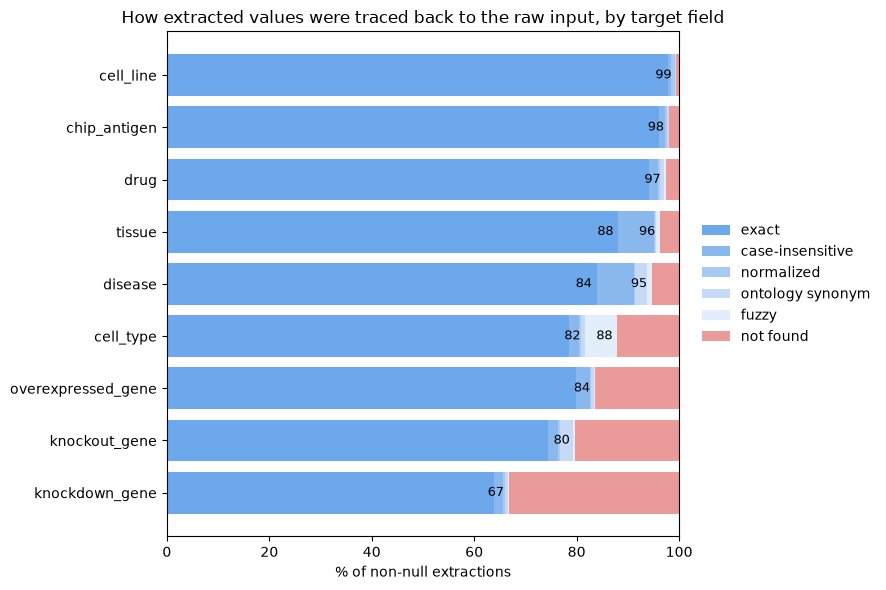

In [7]:
# STACKED PLOT: % OF EXTRACTIONS FOUND PER TIER, PER TARGET FIELD
def _select_label_positions(candidates: list[float], min_gap: float = 6.0) -> list[float]:
    """From candidate label positions (cumulative % boundaries on one bar), picks which to
    actually render as text: always the largest, then each next-largest only if it's at
    least `min_gap` percentage points from the last one kept -- otherwise two close
    boundaries produce overlapping, unreadable text (e.g. 58% and 59% back to back).
    """
    ordered = sorted(set(candidates), reverse=True)
    kept: list[float] = []
    for value in ordered:
        if not kept or (kept[-1] - value) >= min_gap:
            kept.append(value)
    return kept


def plot_strategy_breakdown(stats: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    order = STRATEGY_ORDER
    colors = {
        "exact": "#6da7ec",
        "case-insensitive": "#89b8ef",
        "normalized": "#a8c9f4",
        "ontology synonym": "#c6daf8",
        "fuzzy": "#e3eefc",
        "not found": "#eb9a9a",
    }

    fields = stats.sort_values("pct_found")["target_field"].tolist()
    pct = stats.set_index("target_field")
    pct = pct[order].div(pct["n_with_value"], axis=0) * 100
    pct = pct.loc[fields]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = list(range(len(fields)))
    left = pd.Series(0.0, index=pct.index)
    for strategy in order:
        ax.barh(y_pos, pct[strategy], left=left, label=strategy, color=colors[strategy])
        left += pct[strategy]

    for y, field in zip(y_pos, fields):
        cum = 0.0
        candidates = []
        for strategy in MATCH_STRATEGIES:
            cum += pct.loc[field, strategy]
            if pct.loc[field, strategy] > 0:
                candidates.append(cum)
        for value in _select_label_positions(candidates):
            ax.text(value - 1, y, f"{value:.0f}", va="center", ha="right", fontsize=9, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fields)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of non-null extractions")
    ax.set_title("How extracted values were traced back to the raw input, by target field")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


plot_strategy_breakdown(strategy_stats)

Every target field traces back deterministically for the large majority of its values, mostly via the strongest (`exact`/`case-insensitive`) tiers -- the weaker tiers (`ontology synonym`, `fuzzy`) and `not found` only matter at the margins.
The rest of this notebook assumes this trace-back is largely reliable and looks at what it reveals about the raw field-naming landscape, not at improving the trace-back rate itself (see the pilot notebook for that).

## How many raw field names feed each target field?

Each of the 9 target fields is filled in from evidence scattered across many differently-named raw metadata fields -- this is the reason an LLM was used at all, rather than a fixed list of known field-name synonyms. `n_unique_raw_field` is the literal count of distinct raw field name strings; `n_unique_normalized` re-counts after a basic regex normalization (lowercase, strip `-`, `/`, `|`, `_`, `.`, and whitespace entirely) that merges spelling variants of the same name (`"cell type"`, `"cell_type"`, `"celltype"` all become `"celltype"`).

In [8]:
# UNIQUE RAW FIELD NAMES PER TARGET FIELD, RAW VS. REGEX-NORMALIZED
def field_diversity_table(exploded: pd.DataFrame) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            "n_unique_raw_field": exploded.groupby("target_field")["raw_field"].nunique(),
            "n_unique_normalized": exploded.groupby("target_field")["raw_field_norm"].nunique(),
        }
    )
    table["pct_reduction"] = 100 * (1 - table["n_unique_normalized"] / table["n_unique_raw_field"])
    return table.sort_values("n_unique_raw_field", ascending=False)


diversity_table = field_diversity_table(exploded)
diversity_table.style.format({"n_unique_raw_field": "{:,}", "n_unique_normalized": "{:,}", "pct_reduction": "{:.1f}%"})

,n_unique_raw_field,n_unique_normalized,pct_reduction
target_field,,,
cell_line,"1,466","1,358",7.4%
drug,"1,462","1,366",6.6%
overexpressed_gene,"1,324","1,256",5.1%
knockout_gene,"1,215","1,142",6.0%
tissue,"1,039",951,8.5%
chip_antigen,966,887,8.2%
disease,943,873,7.4%
cell_type,808,725,10.3%
knockdown_gene,704,664,5.7%


In [9]:
# POOLED ACROSS ALL 9 TARGET FIELDS
n_pooled_raw = exploded["raw_field"].nunique()
n_pooled_norm = exploded["raw_field_norm"].nunique()
md(
    f"Pooled across all target fields, there are **{n_pooled_raw:,}** distinct raw field name strings, "
    f"reduced to **{n_pooled_norm:,}** ({100 * (1 - n_pooled_norm / n_pooled_raw):.1f}% fewer) after normalization -- "
    "a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one."
)

Pooled across all target fields, there are **6,013** distinct raw field name strings, reduced to **5,534** (8.0% fewer) after normalization -- a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one.

## Which raw fields actually carry the evidence, and how concentrated is that?

Per target field, its top 20 raw source fields by share of matched evidence, with everything past that collapsed into a single `other` bucket -- the concrete answer to "which few field names should a curator actually prioritize checking?" for each target field.

In [10]:
# TOP RAW FIELDS PER TARGET FIELD, BY % SHARE OF THAT FIELD'S MATCHED EVIDENCE
def top_raw_fields_per_target(exploded: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        total_n = counts.sum()
        top = counts.head(top_n)
        parts = [f"<b>{html.escape(field)}</b> ({100 * n / total_n:.0f}%)" for field, n in top.items()]
        n_other_fields = len(counts) - len(top)
        if n_other_fields > 0:
            parts.append(f"<b>other</b> ({n_other_fields:,} fields, {100 * (total_n - top.sum()) / total_n:.0f}%)")
        rows.append({"target_field": target_field, "total_n": total_n, "top_raw_fields": RawHTML(", ".join(parts))})
    return pd.DataFrame(rows).sort_values("total_n", ascending=False)


top_fields = top_raw_fields_per_target(exploded)
display_with_nested_tables(top_fields.assign(total_n=top_fields["total_n"].map("{:,}".format)))

target_field,total_n,top_raw_fields
tissue,"2,939,282","tissue (58%), source_name (13%), organism part (7%), body site (7%), cell type (3%), histological type (1%), biospecimen repository sample id (1%), submitted sample id (1%), disease (1%), isolate (1%), cell_type (0%), title (0%), sample type (0%), study name (0%), comment (0%), tissue type (0%), brain region (0%), cell line (0%), organ (0%), tissue_type (0%), other (1,019 fields, 5%)"
cell_type,"1,745,321","cell type (70%), cell_type (7%), source_name (5%), tissue (3%), histological type (2%), celltype (1%), title (1%), cell line (1%), inferred cell type (1%), cell cluster (0%), tissue/cell type (0%), cell (0%), comment (0%), tissue/celltype (0%), ArrayExpress-CellType (0%), inferred_cell_type (0%), isolate (0%), developmental stage (0%), ArrayExpress-CELL_TYPE (0%), treatment (0%), other (788 fields, 5%)"
cell_line,"1,064,354","cell line (52%), cell_line (23%), source_name (5%), cell type (4%), tissue (2%), isolate (2%), title (1%), biomaterial_provider (1%), Submitter Id (1%), treatment (1%), growth condition (1%), cell_type (1%), strain (1%), comment (0%), histological type (0%), cell (0%), body site (0%), genotype (0%), stimulus (0%), cell line background (0%), other (1,446 fields, 4%)"
drug,"920,800","treatment (54%), comment (13%), chemical_name (12%), title (2%), agent (1%), Compound (1%), stimulus (1%), sample_name (1%), chemical name (1%), study name (1%), Submitter Id (1%), source_name (1%), isolate (1%), drug treatment (0%), chemical (0%), drug (0%), treatments (0%), condition (0%), group (0%), stimulation (0%), other (1,442 fields, 9%)"
disease,"655,809","disease (24%), disease state (9%), study disease (9%), source_name (8%), tissue (7%), study name (7%), cell type (7%), diagnosis (3%), isolate (1%), histological type (1%), diseaseseverity (1%), title (1%), condition (1%), cell line (1%), health state (1%), patient diagnosis (1%), diabetes (1%), subject status (1%), health_state (1%), treatment (1%), other (923 fields, 15%)"
knockout_gene,"386,435","genotype (51%), comment (8%), title (7%), genotype/variation (5%), strain (4%), treatment (3%), source_name (2%), cell line (1%), Submitter Id (1%), cell type (1%), isolate (1%), group (1%), sample_name (0%), full_genotype (0%), sample description (0%), phenotype (0%), sample (0%), RefGroup (0%), donor genotype (0%), tissue (0%), other (1,195 fields, 11%)"
chip_antigen,"373,644","comment (35%), chip antibody (23%), antibody (9%), title (6%), phenotype (5%), facs marker (3%), immunophenotype (2%), genotype (1%), treatment (1%), cell type (1%), source_name (1%), Submitter Id (1%), target (1%), chip-antibody (1%), antibody antibodydescription (0%), antibodies (0%), sample_name (0%), ChIP (0%), genotype/variation (0%), antibodies/tags (0%), other (946 fields, 9%)"
overexpressed_gene,"200,675","genotype (26%), treatment (9%), title (7%), comment (6%), genotype/variation (6%), strain (5%), source_name (3%), cell type (3%), cell line (2%), transgene (2%), induction (1%), phenotype (1%), transduction (1%), transfection (1%), tissue (1%), Submitter Id (1%), sample_name (1%), isolate (1%), expression (1%), condition (0%), other (1,304 fields, 21%)"
knockdown_gene,"67,982","genotype (21%), treatment (19%), title (10%), comment (6%), genotype/variation (4%), sirna (3%), shRNA (2%), source_name (2%), Submitter Id (1%), knockdown (1%), isolate (1%), transfection (1%), shRNA geneid (1%), cell type (1%), condition (1%), sample_name (1%), transduction (1%), cell line (1%), chip antibody (1%), rna interference (0%), other (684 fields, 23%)"


### How concentrated is that evidence, exactly?

The table above hides how "concentrated" each field's evidence really is, since `other` lumps everything past the top 20 into one number. Concentration is just: if you only ever checked a field's *N* most-used raw field names, what % of all its matched evidence would you actually cover? The chart below shows this at *N* = 1, 5, and 20 raw fields, per target field -- bars close together and near 100% mean a handful of names dominate; bars that keep climbing from top-1 to top-20 mean the evidence is genuinely scattered across many differently-named fields. The table underneath gives the exact number of fields needed to reach 90% coverage.

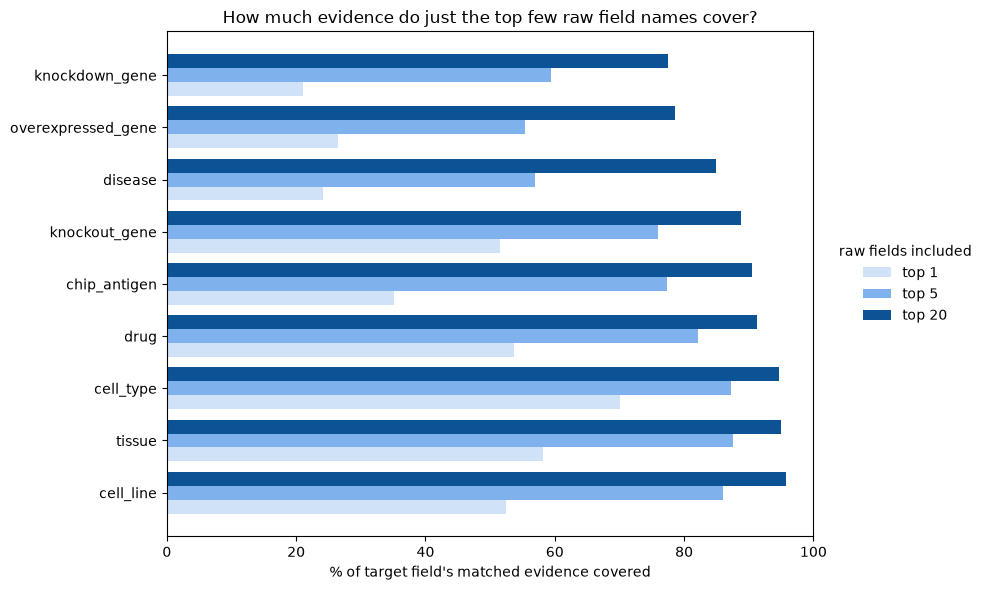

In [11]:
# % OF EVIDENCE COVERED BY THE TOP 1 / 5 / 20 RAW FIELDS, PER TARGET FIELD
def plot_concentration_at_thresholds(
    exploded: pd.DataFrame, thresholds: tuple[int, ...] = (1, 5, 20), figsize: tuple[float, float] = (10, 6)
) -> None:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        for t in thresholds:
            capped = min(t, len(curve))
            rows.append({"target_field": target_field, "top_n": t, "pct_covered": curve.loc[curve["n_fields"] == capped, "pct_covered"].iloc[0]})
    table = pd.DataFrame(rows).pivot(index="target_field", columns="top_n", values="pct_covered")
    table = table.loc[table[thresholds[-1]].sort_values(ascending=False).index]

    colors = ["#cfe2f7", "#7fb2ec", "#0b5394"]
    bar_height = 0.8 / len(thresholds)
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = range(len(table))
    for i, t in enumerate(thresholds):
        offsets = [y + i * bar_height for y in y_pos]
        ax.barh(offsets, table[t], height=bar_height, label=f"top {t}", color=colors[i % len(colors)])
    ax.set_yticks([y + bar_height * (len(thresholds) - 1) / 2 for y in y_pos])
    ax.set_yticklabels(table.index)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of target field's matched evidence covered")
    ax.set_title("How much evidence do just the top few raw field names cover?")
    ax.legend(title="raw fields included", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


plot_concentration_at_thresholds(exploded)

In [12]:
# HOW MANY TOP RAW FIELDS ARE NEEDED TO COVER 90% OF EACH TARGET FIELD'S EVIDENCE
def fields_to_reach(exploded: pd.DataFrame, threshold: float = 90.0) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        n_needed = int(curve.loc[curve["pct_covered"] >= threshold, "n_fields"].min())
        rows.append({"target_field": target_field, "n_fields_total": len(counts), f"n_fields_for_{int(threshold)}pct": n_needed})
    return pd.DataFrame(rows).sort_values(f"n_fields_for_{int(threshold)}pct")


fields_to_reach(exploded)

,target_field,n_fields_total,n_fields_for_90pct
0,cell_line,1466,8
1,cell_type,808,8
8,tissue,1039,8
4,drug,1462,16
2,chip_antigen,966,18
6,knockout_gene,1215,24
3,disease,943,31
7,overexpressed_gene,1324,103
5,knockdown_gene,704,105


Fields like `cell_type`/`tissue`/`cell_line` are dominated by a small handful of raw field names -- most of the "8,000+ different fields" problem for these is a long tail that barely matters in volume.
Fields like `disease`/`knockout_gene`/`overexpressed_gene`/`knockdown_gene` need many more distinct raw fields to cover the same share of evidence -- their information really is scattered across a wider variety of submitter-chosen field names, which is exactly the harder case an LLM-based approach is for.

## Long tail: how much of the diversity is one-off, rarely-used field names?

Per target field: what fraction of its unique raw field names are used only once anywhere in the crate (`singleton`), and what fraction of that field's TOTAL matched evidence those singletons account for. This directly answers how much of the raw naming diversity is noise (one-off names contributing almost nothing) vs. names that recur enough to matter.

In [13]:
# SINGLETON RAW FIELD NAMES, PER TARGET FIELD
def singleton_stats(exploded: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        singletons = counts[counts == 1]
        rows.append(
            {
                "target_field": target_field,
                "n_unique_raw_field": len(counts),
                "n_singleton_fields": len(singletons),
                "pct_fields_singleton": 100 * len(singletons) / len(counts),
                "pct_evidence_from_singletons": 100 * singletons.sum() / counts.sum(),
            }
        )
    return pd.DataFrame(rows).sort_values("pct_fields_singleton", ascending=False)


singleton_stats(exploded).style.format(
    {"n_unique_raw_field": "{:,}", "n_singleton_fields": "{:,}", "pct_fields_singleton": "{:.1f}%", "pct_evidence_from_singletons": "{:.3f}%"}
)

,target_field,n_unique_raw_field,n_singleton_fields,pct_fields_singleton,pct_evidence_from_singletons
1,cell_type,808,121,15.0%,0.007%
7,overexpressed_gene,"1,324",134,10.1%,0.067%
3,disease,943,88,9.3%,0.013%
2,chip_antigen,966,86,8.9%,0.023%
6,knockout_gene,"1,215",102,8.4%,0.026%
5,knockdown_gene,704,57,8.1%,0.084%
4,drug,"1,462",112,7.7%,0.012%
8,tissue,"1,039",64,6.2%,0.002%
0,cell_line,"1,466",73,5.0%,0.007%


A large share of each target field's raw-field vocabulary is used exactly once, but those singletons account for a negligible share of actual evidence -- confirming that the "8,000+ fields" figure is dominated by rarely-used, idiosyncratic names, and that the LLM's job is really about a much smaller, tractable set of recurring names plus a long noisy tail.

## Owner/lab-driven diversity: who introduces the one-off field names?

Is the raw naming diversity concentrated in a few prolific labs/BioProjects each inventing many idiosyncratic field names, or is it genuinely widespread -- many different submitters each contributing just one or two of their own? Checked two ways: how many distinct owners contribute the singleton field names found above, and how concentrated overall field-name usage is across owners (does the top 1% of owners, by how many distinct raw field names they use, account for most of the total usage?).

In [14]:
# SINGLETON FIELD NAMES: HOW MANY DISTINCT OWNERS CONTRIBUTE THEM
def singleton_owner_stats(exploded: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        sub = exploded[exploded["target_field"] == target_field]
        counts = sub["raw_field"].value_counts()
        singleton_fields = counts[counts == 1].index
        singleton_rows = sub[sub["raw_field"].isin(singleton_fields)]
        rows.append(
            {
                "target_field": target_field,
                "n_singleton_fields": len(singleton_fields),
                "n_distinct_owners": singleton_rows["owner"].nunique(),
            }
        )
    return pd.DataFrame(rows)


singleton_owner_stats(exploded)

,target_field,n_singleton_fields,n_distinct_owners
0,cell_line,73,50
1,cell_type,121,45
2,chip_antigen,86,74
3,disease,88,53
4,drug,112,90
5,knockdown_gene,57,43
6,knockout_gene,102,83
7,overexpressed_gene,134,102
8,tissue,64,55


In [15]:
# CONCENTRATION OF RAW-FIELD-NAME USAGE ACROSS OWNERS: WHAT SHARE DOES THE TOP 1% OF OWNERS ACCOUNT FOR
def owner_concentration(exploded: pd.DataFrame, target_field: str, top_frac: float = 0.01) -> pd.Series:
    per_owner = exploded.loc[exploded["target_field"] == target_field].groupby("owner")["raw_field"].nunique().sort_values(ascending=False)
    n_top = max(1, int(len(per_owner) * top_frac))
    return pd.Series(
        {
            "n_owners": len(per_owner),
            "n_top_owners": n_top,
            "pct_of_field_mentions_from_top_1pct_owners": 100 * per_owner.iloc[:n_top].sum() / per_owner.sum(),
        }
    )


owner_concentration_table = pd.DataFrame({tf: owner_concentration(exploded, tf) for tf in TARGET_FIELDS}).T
owner_concentration_table.style.format({"n_owners": "{:,.0f}", "n_top_owners": "{:,.0f}", "pct_of_field_mentions_from_top_1pct_owners": "{:.1f}%"})

,n_owners,n_top_owners,pct_of_field_mentions_from_top_1pct_owners
cell_line,"17,816",178,8.9%
cell_type,"22,415",224,6.2%
chip_antigen,"6,238",62,7.5%
disease,"10,030",100,8.2%
drug,"14,531",145,7.2%
knockdown_gene,"4,909",49,7.5%
knockout_gene,"11,315",113,7.6%
overexpressed_gene,"7,250",72,8.1%
tissue,"27,392",273,6.2%


The singleton field names come from nearly as many distinct owners as there are singleton fields -- i.e. mostly one owner per one-off name, not one lab spamming many idiosyncratic names -- and the top 1% of owners (by how many distinct raw field names they each use) account for only a modest share of total usage. The naming diversity looks like genuinely widespread, independent variation across many submitters, not a small number of labs driving most of the noise.

## Structured vs. free-text sources, and how that mix changes over time

Classifying each raw field name into three groups, per target field: **in the field** (the raw field name literally *is* the target field -- e.g. `cell_line`/`cell line`/`Cell-Line` all count as "in the field" for target field `cell_line`), **other structured** (named after a *different* specific biological property -- `tissue`, `genotype`, ... -- even when its own content is itself free-form text), or **free-text** (a generic, submitter-authored catch-all container -- `title`, `source_name`, `comment`, ...). Shown both as an overall breakdown per target field, and as a year-by-year trend pooled across all target fields.

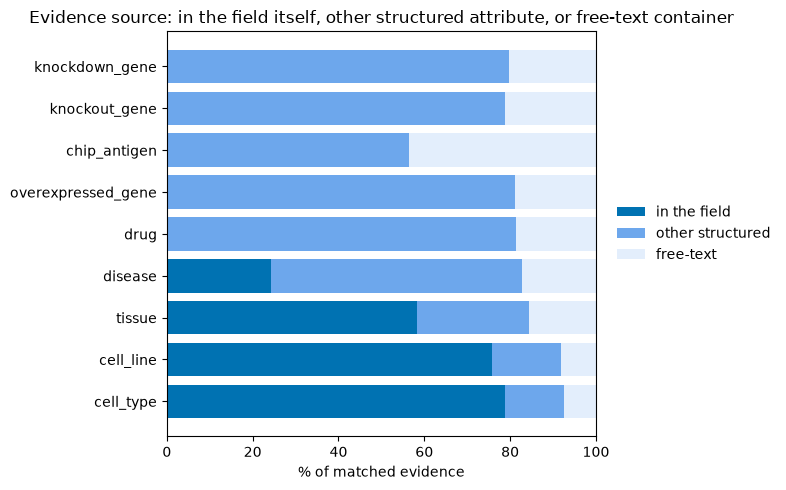

In [16]:
# % OF MATCHED EVIDENCE: IN THE TARGET FIELD ITSELF, OTHER STRUCTURED FIELD, OR FREE-TEXT, PER TARGET FIELD
EVIDENCE_SOURCE_ORDER = ["in the field", "other structured", "free-text"]
EVIDENCE_SOURCE_COLORS = {"in the field": "#0072B2", "other structured": "#6da7ec", "free-text": "#e3eefc"}


def classify_evidence_source(exploded: pd.DataFrame) -> pd.Series:
    target_norm = exploded["target_field"].map(normalize_field_name)
    in_field = exploded["raw_field_norm"] == target_norm
    return pd.Series(np.select([in_field, exploded["is_free_text"]], ["in the field", "free-text"], default="other structured"), index=exploded.index)


exploded["evidence_source"] = classify_evidence_source(exploded)


def evidence_source_breakdown(exploded: pd.DataFrame) -> pd.DataFrame:
    counts = exploded.groupby(["target_field", "evidence_source"]).size().unstack(fill_value=0)
    pct = 100 * counts.div(counts.sum(axis=1), axis=0)
    return pct[EVIDENCE_SOURCE_ORDER].sort_values("in the field", ascending=False)


def plot_evidence_source_breakdown(pct: pd.DataFrame, figsize: tuple[float, float] = (8, 5)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = range(len(pct))
    left = pd.Series(0.0, index=pct.index)
    for source in EVIDENCE_SOURCE_ORDER:
        ax.barh(y_pos, pct[source], left=left, label=source, color=EVIDENCE_SOURCE_COLORS[source])
        left += pct[source]
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pct.index)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of matched evidence")
    ax.set_title("Evidence source: in the field itself, other structured attribute, or free-text container")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


evidence_source_table = evidence_source_breakdown(exploded)
plot_evidence_source_breakdown(evidence_source_table)

### How does this mix change over time?

Same three categories, pooled across all target fields, per calendar year -- using `year_publication` since (unlike `year_submission`) it has no missing values.

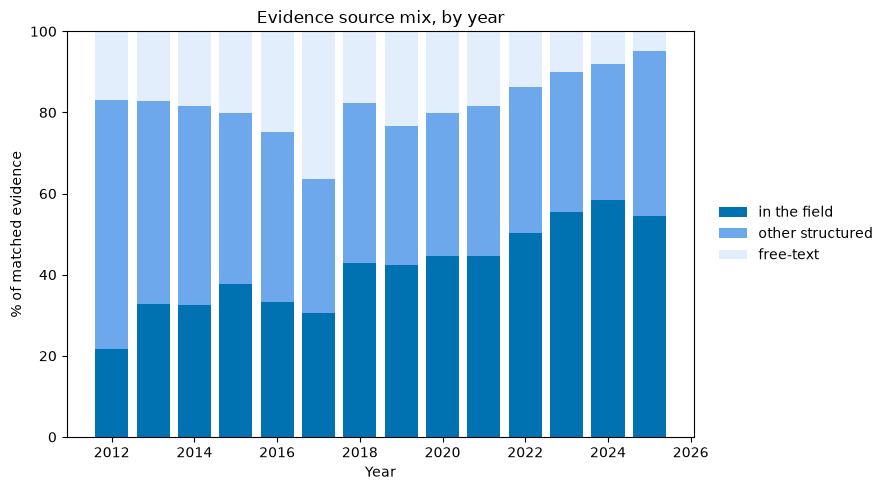

In [17]:
# % OF MATCHED EVIDENCE PER YEAR, BY EVIDENCE SOURCE (POOLED ACROSS TARGET FIELDS)
def evidence_source_over_time(exploded: pd.DataFrame, date_col: str = "year_publication") -> pd.DataFrame:
    sub = exploded.dropna(subset=[date_col])
    sub = sub[sub[date_col].between(*YEAR_RANGE)]
    counts = sub.groupby([date_col, "evidence_source"]).size().unstack(fill_value=0)
    return (100 * counts.div(counts.sum(axis=1), axis=0))[EVIDENCE_SOURCE_ORDER]


def plot_evidence_source_over_time(pct: pd.DataFrame, date_col: str = "year_publication", figsize: tuple[float, float] = (9, 5)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    bottom = pd.Series(0.0, index=pct.index)
    for source in EVIDENCE_SOURCE_ORDER:
        ax.bar(pct.index, pct[source], bottom=bottom, label=source, color=EVIDENCE_SOURCE_COLORS[source])
        bottom += pct[source]
    ax.set_xlabel("Year")
    ax.set_ylabel("% of matched evidence")
    ax.set_ylim(0, 100)
    ax.set_title("Evidence source mix, by year")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


evidence_source_trend = evidence_source_over_time(exploded)
plot_evidence_source_over_time(evidence_source_trend)

The free-text share is not a simple decline: it RISES from 2012 to a peak around 2017, then falls steadily and substantially through 2025 -- growing "in the field" and "other structured" share correspondingly.

The post-2017 decline (the larger, more sustained part of the pattern) lines up plausibly -- not provably from this data alone -- with the broader push toward structured, checklist-driven metadata submission over the last decade: NCBI/DDBJ's harmonized-attribute BioSample packages, MIxS/MIAME-style minimum-information checklists, and journal/funder data-sharing mandates requiring structured sample metadata have all become more consistently enforced industry-wide since roughly the late 2010s.

The pre-2017 rise doesn't fit that story as neatly, and could instead reflect which submitters/BioProjects happened to dominate the crate's earlier years rather than a field-wide behavior change -- confirming either direction would need comparing against actual standards-rollout dates and per-submitter breakdowns, which is out of scope here.

The pooled year-trend charts further below (rarefied unique raw-field count) show a similar late-decline shape -- diversity rising to a peak around 2020-2021 then falling through 2025 -- consistent with the same recent-years story.

## Match-strategy quality vs. raw-field-name diversity

Does a target field that draws on more differently-named raw fields also rely more on the WEAKER trace-back tiers (`ontology synonym`, `fuzzy` -- see the recap above), or is match quality unrelated to naming diversity?

In [18]:
# % OF FOUND EVIDENCE VIA WEAK TIERS, VS. RAW-FIELD-NAME DIVERSITY, PER TARGET FIELD
def strategy_vs_diversity(trace_back: pd.DataFrame, exploded: pd.DataFrame) -> pd.DataFrame:
    strategy_counts = trace_back.groupby(["target_field", "strategy"]).size().unstack(fill_value=0)
    weak = strategy_counts.get("fuzzy", 0) + strategy_counts.get("ontology synonym", 0)
    total_found = strategy_counts.drop(columns=["not found"], errors="ignore").sum(axis=1)
    table = pd.DataFrame(
        {
            "pct_weak_tier_evidence": 100 * weak / total_found,
            "n_unique_raw_field": exploded.groupby("target_field")["raw_field"].nunique(),
            "n_unique_normalized": exploded.groupby("target_field")["raw_field_norm"].nunique(),
        }
    ).sort_values("pct_weak_tier_evidence")
    return table


strategy_diversity_table = strategy_vs_diversity(trace_back, exploded)
strategy_diversity_table.style.format({"pct_weak_tier_evidence": "{:.2f}%", "n_unique_raw_field": "{:,}", "n_unique_normalized": "{:,}"})

,pct_weak_tier_evidence,n_unique_raw_field,n_unique_normalized
target_field,,,
cell_line,0.23%,"1,466","1,358"
chip_antigen,0.37%,966,887
tissue,1.02%,"1,039",951
drug,1.03%,"1,462","1,366"
overexpressed_gene,1.03%,"1,324","1,256"
knockdown_gene,1.23%,704,664
disease,3.46%,943,873
knockout_gene,3.58%,"1,215","1,142"
cell_type,8.02%,808,725


In [19]:
# CORRELATION: DOES MORE RAW-FIELD DIVERSITY MEAN MORE RELIANCE ON WEAK-TIER MATCHES?
corr = strategy_diversity_table["pct_weak_tier_evidence"].corr(strategy_diversity_table["n_unique_raw_field"])
md(
    f"Correlation across the 9 target fields between % weak-tier evidence and raw-field-name diversity: **{corr:.2f}**. "
    + ("A weak/inconclusive relationship" if abs(corr) < 0.5 else "A fairly strong relationship")
    + " -- naming diversity alone does not cleanly predict how often the pipeline had to fall back on its weakest tiers; other factors (how literally the value is restated in free text, ontology coverage for that field) matter too."
)

Correlation across the 9 target fields between % weak-tier evidence and raw-field-name diversity: **-0.44**. A weak/inconclusive relationship -- naming diversity alone does not cleanly predict how often the pipeline had to fall back on its weakest tiers; other factors (how literally the value is restated in free text, ontology coverage for that field) matter too.

## Biosample-level vs. BioProject-level: does field-name usage look different?

The same raw field can dominate very differently depending on whether you count by BIOSAMPLE (a BioProject with many samples counts many times) or by BIOPROJECT (each contributes once per field it uses, however many samples it has) -- a field used by a few huge BioProjects looks dominant at the sample level but marginal at the BioProject level, and vice versa. BioProject linkage isn't in the raw crate for every record, so this is restricted to records where it could be resolved (see the coverage figures below) and uses each record's first/primary linked BioProject only.

### Why isn't every record linked to a BioProject?

This isn't a gap in this pipeline's parsing -- inspecting the raw JSON directly confirms the link is genuinely absent from the record itself, for three distinct reasons tied to *where* the record originally came from (its accession prefix):
- **EBI/ENA-origin records** (`SAMEA`, often imported via ArrayExpress) use ENA's own "Study" concept instead of NCBI's BioProject system, and carry no `Links.Link` entry with `target: "bioproject"` in this schema at all -- there is nothing to find here, in this record or any API built on this same schema.
- **Old NCBI records** (`SAMN`, mostly pre-2011/2012) predate NCBI's BioProject umbrella becoming mandatory -- their `Attributes` block is often simply `null`, with no `Links` section either.
- **Some DDBJ records** (`SAMD`) were submitted with only a bare SRA/DRA run link and no explicit BioProject attribute or link.

The table below breaks coverage down by this origin-archive split, which explains the gap far better than the target-field or category breakdowns above/below it.

In [20]:
# BIOPROJECT LINKAGE COVERAGE, BY TARGET FIELD, CATEGORY, AND ORIGIN ARCHIVE
md("**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by target field:")
coverage_by_field = (100 * exploded.groupby("target_field")["bioproject_id"].apply(lambda s: s.notna().mean())).rename("pct_with_bioproject").to_frame()
display(coverage_by_field.style.format("{:.1f}%"))

md("...and by category -- ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset:")
coverage_by_category = (100 * exploded.groupby("category")["bioproject_id"].apply(lambda s: s.notna().mean())).rename("pct_with_bioproject").to_frame()
display(coverage_by_category.style.format("{:.1f}%"))

ORIGIN_ARCHIVE_BY_PREFIX = {"SAMN": "NCBI (SAMN)", "SAMD": "DDBJ (SAMD)", "SAME": "EBI/ENA (SAMEA)"}
exploded["origin_archive"] = exploded["accession"].str[:4].map(ORIGIN_ARCHIVE_BY_PREFIX)

md("...and by origin archive (accession prefix) -- the real driver of the gap, see above:")
coverage_by_origin = (100 * exploded.groupby("origin_archive")["bioproject_id"].apply(lambda s: s.notna().mean())).rename("pct_with_bioproject").to_frame()
display(coverage_by_origin.style.format("{:.1f}%"))

by_accession = exploded.drop_duplicates("accession")[["accession", "bioproject_id", "origin_archive"]]
missing = by_accession[by_accession["bioproject_id"].isna()]
missing_by_origin = missing["origin_archive"].value_counts()
md(
    f"Across the **{len(by_accession):,}** distinct BioSamples with at least one traced-back evidence value, **{len(missing):,}** "
    f"({100 * len(missing) / len(by_accession):.1f}%) have no resolvable BioProject: "
    f"**{missing_by_origin.get('EBI/ENA (SAMEA)', 0):,}** are EBI/ENA-origin (100% of that origin, by construction -- see above), "
    f"**{missing_by_origin.get('NCBI (SAMN)', 0):,}** are NCBI records (mostly pre-BioProject-era), "
    f"and **{missing_by_origin.get('DDBJ (SAMD)', 0):,}** are DDBJ records submitted without one."
)

**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by target field:

,pct_with_bioproject
target_field,
cell_line,86.8%
cell_type,85.7%
chip_antigen,51.9%
disease,67.3%
drug,81.5%
knockdown_gene,86.9%
knockout_gene,79.1%
overexpressed_gene,83.6%
tissue,77.5%


...and by category -- ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset:

,pct_with_bioproject
category,
ChIP-Atlas,89.8%
DDBJ RNA-Seq,78.0%


...and by origin archive (accession prefix) -- the real driver of the gap, see above:

,pct_with_bioproject
origin_archive,
DDBJ (SAMD),53.0%
EBI/ENA (SAMEA),0.0%
NCBI (SAMN),91.7%


Across the **3,904,912** distinct BioSamples with at least one traced-back evidence value, **635,572** (16.3%) have no resolvable BioProject: **322,216** are EBI/ENA-origin (100% of that origin, by construction -- see above), **293,179** are NCBI records (mostly pre-BioProject-era), and **20,177** are DDBJ records submitted without one.

**Could the missing ones be backfilled through an API?** Partially, and not cheaply. For NCBI (`SAMN`) and DDBJ (`SAMD`) records, NCBI's E-utilities and DDBJ's own REST API can look up an accession's linked BioProject -- and both support batched lookups (NCBI's `efetch`/`esummary` accept up to ~200 accessions per request), so the real bottleneck is API rate limits, not the number of records: hundreds of thousands of missing `SAMN`/`SAMD` accessions would mean thousands of batched requests, likely hours of wall-clock time at NCBI's default (unauthenticated) rate limit. Even then, a real fraction of the missing `SAMN` records are simply from before BioProject existed as a concept -- there is no BioProject to find for them, at any API. For EBI/ENA (`SAMEA`) records, this would need an entirely different API and a different target concept (ENA's "Study" accession, not a BioProject) -- a separate piece of work, not an extension of the same lookup. So a full backfill is a multi-archive engineering effort with a lower ceiling than 100%, not a one-line API call.

### Does the dominant raw field actually differ by counting level?

First, one concrete example (`tissue`): its top raw field names by % share of matched evidence, counted per BioSample vs. per BioProject side by side (`abs_diff_pct_pts` flags where the two views disagree most). Then, summarized across all 9 target fields: how large that per-BioSample-vs-per-BioProject disagreement typically runs, and which single raw field diverges most for each.

In [21]:
# TOP RAW FIELDS BY % SHARE, BIOSAMPLE-LEVEL VS. BIOPROJECT-LEVEL, FOR ONE ILLUSTRATIVE TARGET FIELD
def top_fields_by_level(exploded: pd.DataFrame, target_field: str, top_n: int = 8) -> pd.DataFrame:
    sub = exploded[exploded["target_field"] == target_field]
    sample_share = sub["raw_field"].value_counts(normalize=True).mul(100).rename("pct_of_biosamples")

    by_bioproject = sub.dropna(subset=["bioproject_id"]).drop_duplicates(["bioproject_id", "raw_field"])
    bioproject_share = by_bioproject["raw_field"].value_counts(normalize=True).mul(100).rename("pct_of_bioprojects")

    compare = pd.concat([sample_share, bioproject_share], axis=1).fillna(0.0)
    compare["abs_diff_pct_pts"] = (compare["pct_of_biosamples"] - compare["pct_of_bioprojects"]).abs()
    return compare.sort_values("pct_of_biosamples", ascending=False).head(top_n)


top_fields_by_level(exploded, "tissue").style.format("{:.1f}")

,pct_of_biosamples,pct_of_bioprojects,abs_diff_pct_pts
raw_field,,,
tissue,58.2,72.7,14.5
source_name,12.6,10.9,1.7
organism part,7.1,0.0,7.1
body site,6.7,0.0,6.7
cell type,2.9,6.4,3.5
histological type,1.2,0.0,1.2
biospecimen repository sample id,0.7,0.0,0.7
submitted sample id,0.7,0.0,0.7


In [22]:
# HOW MUCH DO THE TWO LEVELS DISAGREE, ACROSS ALL TARGET FIELDS
def level_diff_summary(exploded: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        sub = exploded[exploded["target_field"] == target_field]
        sample_share = sub["raw_field"].value_counts(normalize=True).mul(100).rename("s")
        by_bioproject = sub.dropna(subset=["bioproject_id"]).drop_duplicates(["bioproject_id", "raw_field"])
        bioproject_share = by_bioproject["raw_field"].value_counts(normalize=True).mul(100).rename("b")
        compare = pd.concat([sample_share, bioproject_share], axis=1).fillna(0.0)
        diff = (compare["s"] - compare["b"]).abs()
        rows.append(
            {
                "target_field": target_field,
                "mean_abs_diff_pct_pts": diff.mean(),
                "max_abs_diff_pct_pts": diff.max(),
                "raw_field_with_max_diff": diff.idxmax(),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_abs_diff_pct_pts", ascending=False)


level_diff_summary(exploded).style.format({"mean_abs_diff_pct_pts": "{:.2f}", "max_abs_diff_pct_pts": "{:.2f}"})

,target_field,mean_abs_diff_pct_pts,max_abs_diff_pct_pts,raw_field_with_max_diff
2,chip_antigen,0.10,34.68,comment
3,disease,0.08,11.98,cell type
5,knockdown_gene,0.06,4.88,treatment
4,drug,0.05,18.24,treatment
8,tissue,0.04,14.48,tissue
7,overexpressed_gene,0.04,5.10,comment
6,knockout_gene,0.03,7.44,comment
1,cell_type,0.03,4.38,cell type
0,cell_line,0.03,12.28,cell_line


The two levels do disagree, sometimes substantially, on individual fields -- a field can look dominant when counted by biosample simply because a handful of very large BioProjects happen to use it, while looking marginal when every BioProject counts equally. Any claim about "the main field submitters use for X" should specify which of the two it means.

## How does raw-field-name diversity vary by year?

Two different, genuinely different dates are available per BioSample: `submission_date` (when the record was first submitted, not always present) and `publication_date` (when it became public, always present). Checked directly below: how often each is missing, and -- for records with both -- how much they actually differ, to decide whether using one instead of the other would materially change a year-based analysis.

In [23]:
# MISSING RATES FOR EACH DATE FIELD
md(
    f"`submission_date` missing for **{100 * metadata['submission_date'].isna().mean():.2f}%** of accessions; "
    f"`publication_date` missing for **{100 * metadata['publication_date'].isna().mean():.2f}%**."
)

`submission_date` missing for **1.02%** of accessions; `publication_date` missing for **0.00%**.

In [24]:
# HOW MUCH DO submission_date AND publication_date DISAGREE, WHERE BOTH EXIST
both_dates = metadata.dropna(subset=["submission_date", "publication_date"]).copy()
both_dates["submission_dt"] = pd.to_datetime(both_dates["submission_date"], format="mixed", utc=True, errors="coerce")
both_dates["publication_dt"] = pd.to_datetime(both_dates["publication_date"], format="mixed", utc=True, errors="coerce")
both_dates = both_dates.dropna(subset=["submission_dt", "publication_dt"])
diff_days = (both_dates["publication_dt"] - both_dates["submission_dt"]).dt.total_seconds() / 86400
n_negative = (diff_days < 0).sum()

md(
    f"Among **{len(both_dates):,}** accessions with both dates, the gap between them (`publication_date - submission_date`): "
    f"median **{diff_days.median():.0f} days**, mean **{diff_days.mean():.0f} days**, "
    f"min **{diff_days.min():,.0f} days**, max **{diff_days.max():,.0f} days**. "
    f"The mean sitting more than double the median, and **{n_negative:,}** records ({100 * n_negative / len(both_dates):.1f}%) showing a NEGATIVE gap -- published before their recorded submission date, up to {abs(diff_days.min()) / 365.25:.0f} years earlier at the extreme -- "
    "suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. "
    f"Only **{100 * (both_dates['submission_dt'].dt.year == both_dates['publication_dt'].dt.year).mean():.1f}%** "
    f"share the same calendar year, and **{100 * (diff_days.abs() <= 90).mean():.1f}%** are within 90 days. "
    "The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one."
)

Among **4,144,993** accessions with both dates, the gap between them (`publication_date - submission_date`): median **96 days**, mean **220 days**, min **-4,448 days**, max **5,671 days**. The mean sitting more than double the median, and **627,894** records (15.1%) showing a NEGATIVE gap -- published before their recorded submission date, up to 12 years earlier at the extreme -- suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. Only **59.1%** share the same calendar year, and **48.8%** are within 90 days. The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one.

### Controlling for how many biosamples/BioProjects exist per year

A year with more biosamples mechanically has more unique raw field names, even with no real change in naming behavior. Every year-trend chart below uses **rarefaction** (from ecological species-richness estimation): each year is repeatedly subsampled down to the same number of units (biosamples, or BioProjects for the BioProject-level charts -- whichever is the smaller across years) before counting unique raw field names, averaged over resamples, so the comparison isn't just tracking how much data exists for that year.

For each of the 4 combinations below (biosample/BioProject level x submission/publication date), two views: a trend line per target field (do individual fields move differently over time?), and one pooled bar chart contrasting raw vs. regex-normalized counts (does normalization close more of the gap in some years than others?).

Restricted to 2012-2025: earlier years have too few records for a stable rarefied estimate, and 2026 is only partially elapsed as of this notebook's run.

In [25]:
# RAREFIED UNIQUE RAW-FIELD COUNT PER YEAR: ONE TREND LINE PER TARGET FIELD, PLUS ONE POOLED AVERAGE BAR CHART
def plot_year_diversity_trend(exploded: pd.DataFrame, date_col: str, unit_col: str, level_label: str, figsize: tuple[float, float] = (9, 6)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    for target_field in TARGET_FIELDS:
        sub = exploded[exploded["target_field"] == target_field].dropna(subset=[date_col, unit_col])
        sub = sub[sub[date_col].between(*YEAR_RANGE)]
        res = rarefied_unique_counts(sub, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
        ax.plot(res[date_col], res["mean_unique"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=2, marker="o", markersize=3)

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rarefied unique raw fields, per {unit_col}")
    ax.set_title(f"Raw-field-name diversity per year, by {level_label} ({date_col})")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()


def plot_year_diversity_average(exploded: pd.DataFrame, date_col: str, unit_col: str, level_label: str, figsize: tuple[float, float] = (9, 6)) -> None:
    sub = exploded.dropna(subset=[date_col, unit_col])
    sub = sub[sub[date_col].between(*YEAR_RANGE)]
    raw_res = rarefied_unique_counts(sub, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
    norm_res = rarefied_unique_counts(sub, date_col, unit_col, "raw_field_norm", n_iter=N_RAREFACTION_ITER)

    fig, ax = plt.subplots(figsize=figsize)
    width = 0.4
    years = raw_res[date_col]
    ax.bar(years - width / 2, raw_res["mean_unique"], width=width, label="raw", color="#6da7ec")
    ax.bar(years + width / 2, norm_res["mean_unique"], width=width, label="normalized", color="#c6daf8")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rarefied unique raw fields (subsampled to {int(raw_res['k'].iloc[0]):,} {unit_col}s/year)")
    ax.set_title(f"All target fields pooled, per {level_label} ({date_col})")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

### By biosample, using `submission_date`

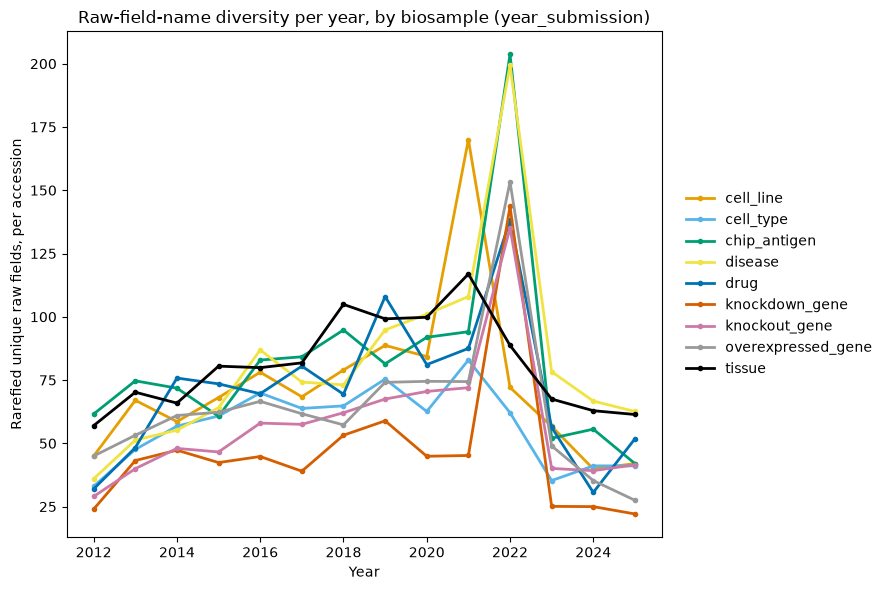

In [26]:
# TREND: RAW-FIELD-NAME DIVERSITY PER YEAR, PER TARGET FIELD, BY BIOSAMPLE, USING submission_date
plot_year_diversity_trend(exploded, "year_submission", "accession", "biosample")

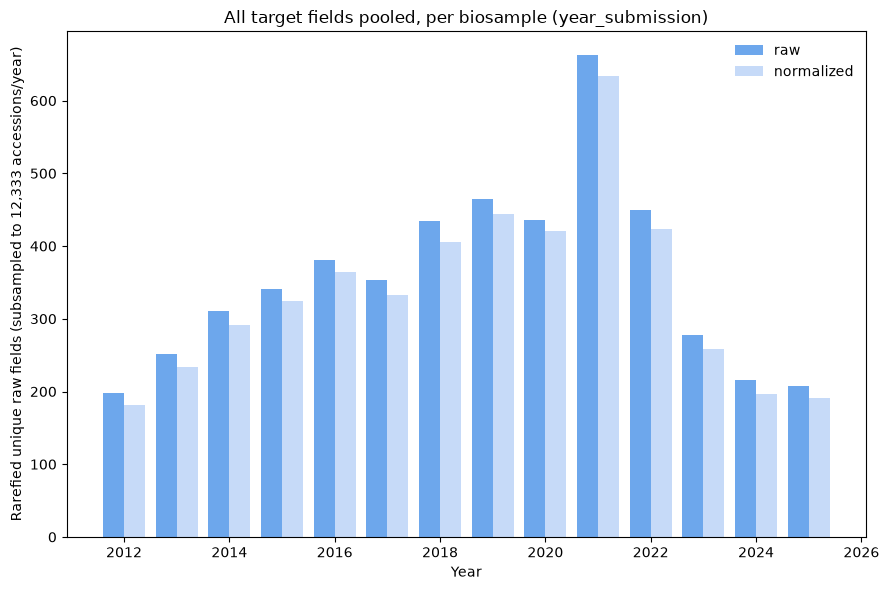

In [27]:
# POOLED AVERAGE: RAW VS. NORMALIZED, BY BIOSAMPLE, USING submission_date
plot_year_diversity_average(exploded, "year_submission", "accession", "biosample")

### By biosample, using `publication_date`

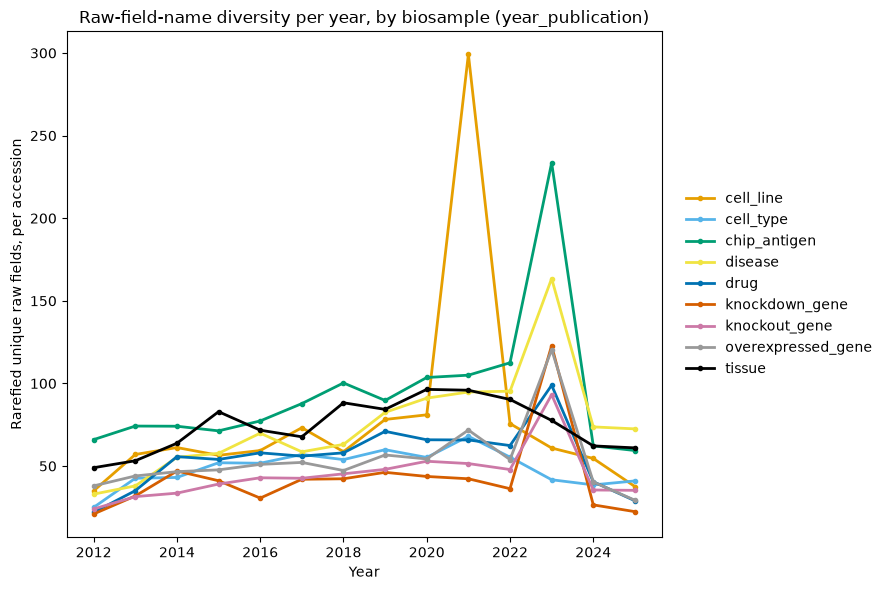

In [28]:
# TREND: RAW-FIELD-NAME DIVERSITY PER YEAR, PER TARGET FIELD, BY BIOSAMPLE, USING publication_date
plot_year_diversity_trend(exploded, "year_publication", "accession", "biosample")

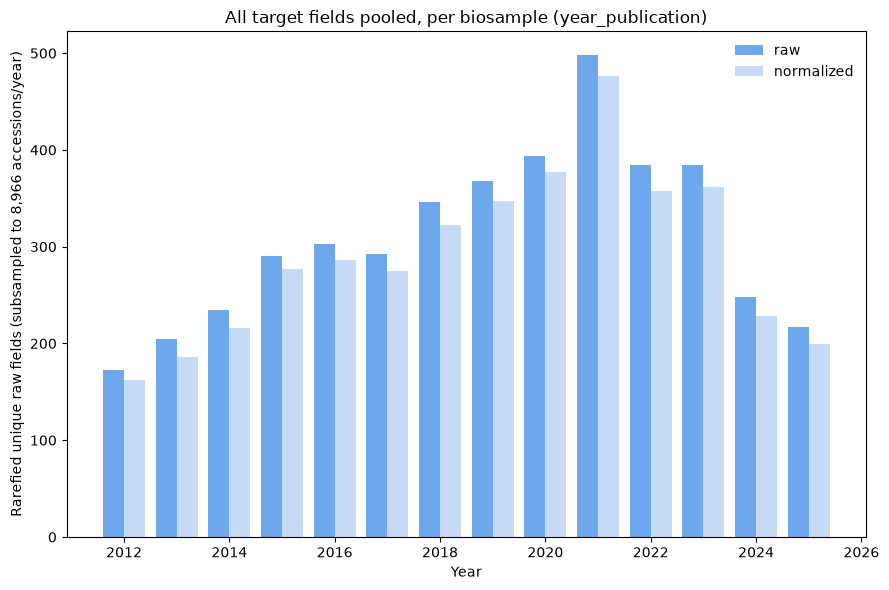

In [29]:
# POOLED AVERAGE: RAW VS. NORMALIZED, BY BIOSAMPLE, USING publication_date
plot_year_diversity_average(exploded, "year_publication", "accession", "biosample")

### By BioProject (average across BioProjects that year), using `submission_date`

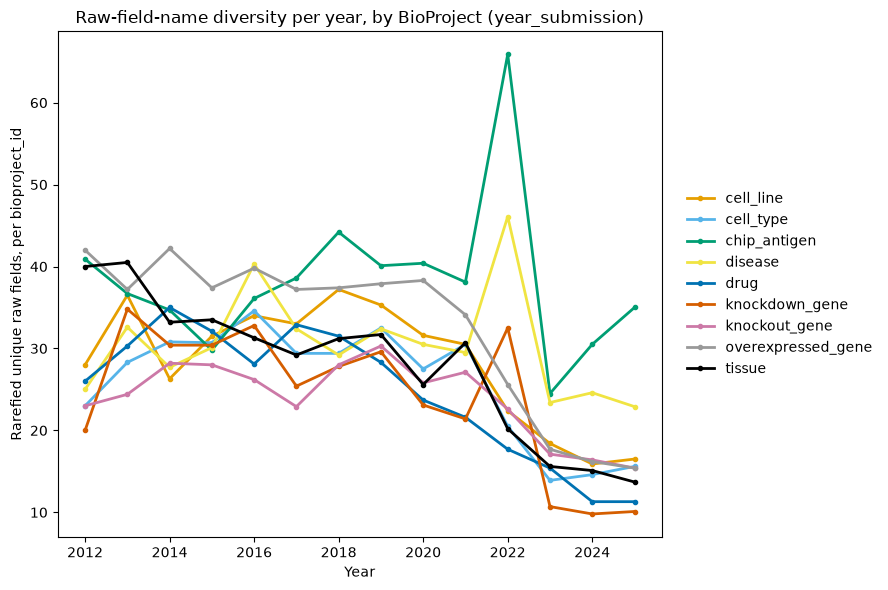

In [30]:
# TREND: RAW-FIELD-NAME DIVERSITY PER YEAR, PER TARGET FIELD, BY BIOPROJECT, USING submission_date
plot_year_diversity_trend(exploded, "year_submission", "bioproject_id", "BioProject")

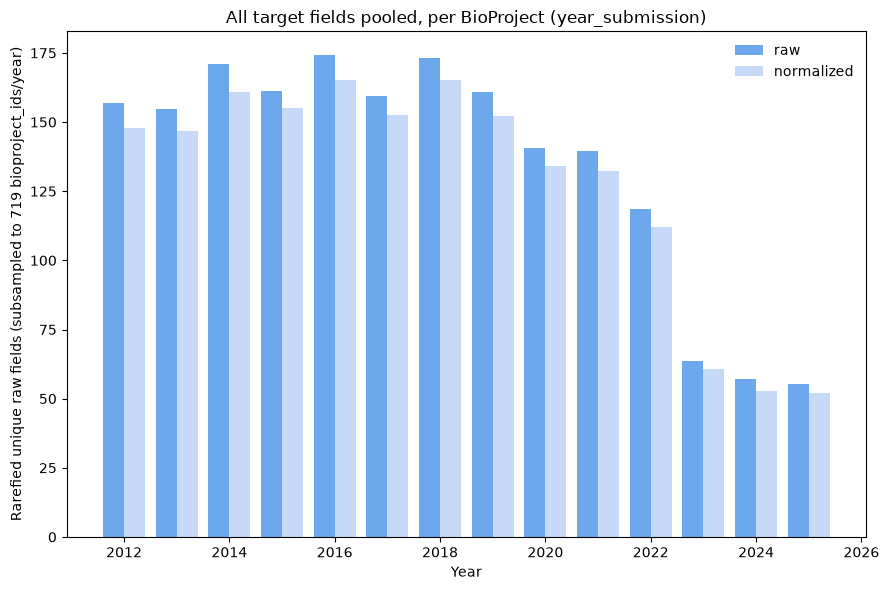

In [31]:
# POOLED AVERAGE: RAW VS. NORMALIZED, BY BIOPROJECT, USING submission_date
plot_year_diversity_average(exploded, "year_submission", "bioproject_id", "BioProject")

### By BioProject (average across BioProjects that year), using `publication_date`

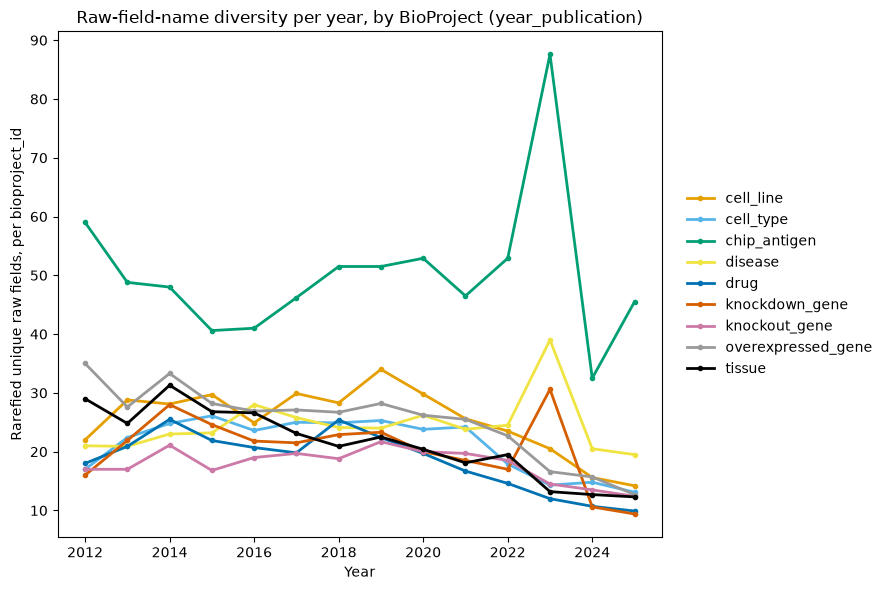

In [32]:
# TREND: RAW-FIELD-NAME DIVERSITY PER YEAR, PER TARGET FIELD, BY BIOPROJECT, USING publication_date
plot_year_diversity_trend(exploded, "year_publication", "bioproject_id", "BioProject")

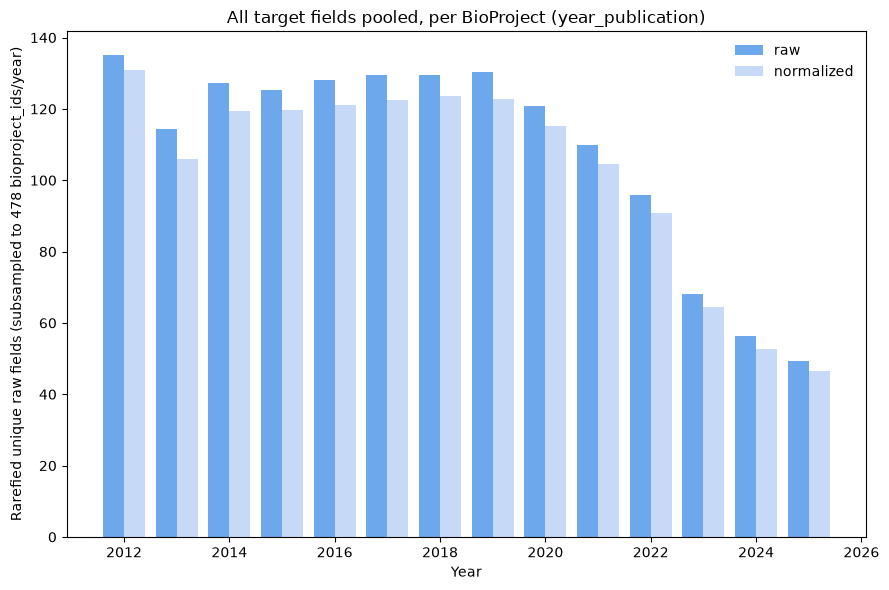

In [33]:
# POOLED AVERAGE: RAW VS. NORMALIZED, BY BIOPROJECT, USING publication_date
plot_year_diversity_average(exploded, "year_publication", "bioproject_id", "BioProject")

## Summary

- The stacked-barplot recap shows the trace-back check itself is working well across all 9 target fields, mostly via the strongest match tiers.
- A modest handful of raw field names account for most evidence for `cell_type`/`tissue`/`cell_line`; `disease`/the gene-perturbation fields need many more distinct raw fields to reach the same coverage.
- Regex normalization (case/separator collapsing) reduces the raw field-name count by a real but modest amount -- most of the diversity is genuinely different names, not spelling variants.
- Most of that diversity is a long tail of singleton, one-off field names contributing negligible evidence, and it's spread across many independent submitting labs rather than concentrated in a few.
- Missing BioProject linkage (~16% of BioSamples) is explained almost entirely by *where* a record originated (EBI/ENA-origin records structurally have none; old NCBI records predate BioProject; some DDBJ records were submitted without one) -- not a gap in this pipeline, and only partially, expensively fixable via API.
- Biosample-level and BioProject-level views of "which field dominates" can disagree substantially for individual target fields.
- Naming diversity by itself doesn't cleanly predict reliance on the trace-back check's weaker match tiers.
- Year-over-year naming diversity (rarefaction-controlled) and the evidence-source mix (in-the-field / other-structured / free-text) both show real movement over the crate's history, worth revisiting once the trace-back job reaches 100%.